# CrowdStrike Pilot — Robustness Checks (v2)
Two robustness analyses for the §3 Preliminary Work writeup:**1. **Matched-sample sentiment test.** Pre/post is 9:1 imbalanced. Subsample post to n = 379 (matched to pre), repeat 200 times, report whether the sentiment effect survives.2. **Extended-stopword LDA.** Re-run topic modeling with additional filler words (`thing`, `way`, `going`, `still`, `time`, `work`, `people`, etc.) dropped, so topics read more cleanly in the proposal.**Input:** `comments_hashed.csv` from v1.**Output:** new figures + `stats_v2.json` to append to v1 results.Runtime: ~2 minutes (no GPU needed).

## 1. Setup

In [1]:
!pip install -q gensim nltk

import nltk
for pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)
print("Setup OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.2 MB/s eta 0:00:00
Setup OK


In [2]:
import json, hashlib, re, io, os
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Apology timestamp (same as v1)
T_APOLOGY = int(datetime(2024, 7, 19, 15, 45, 0, tzinfo=timezone.utc).timestamp())
print("Imports OK")

Imports OK


## 2. Load comments_hashed.csvClick the button below, then select the `comments_hashed.csv` file you downloaded from v1.

In [3]:
from google.colab import files
print("Upload comments_hashed.csv:")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))
print(f"\nLoaded {len(df)} comments")
print(f"Columns: {list(df.columns)}")
print(f"\nBy window:")
print(df['window'].value_counts())

Upload comments_hashed.csv:


Saving comments_hashed.csv to comments_hashed.csv

Loaded 3768 comments
Columns: ['id', 'subreddit', 'author_hash', 'score', 'created_utc', 'window', 'vader', 'vader_label', 'roberta_label', 'roberta_score', 'roberta_signed', 'body']

By window:
window
post    3389
pre      379
Name: count, dtype: int64


## 3. Matched-sample sentiment robustnessThe full-sample test gave **VADER p = 0.027** and **RoBERTa p = 0.0039** — but pre/post is 9:1. The matched test answers: *if the post window had the same n as pre (379), would the effect survive?*Procedure: for each of 200 trials, randomly sample 379 post comments, run Welch's t-test on both VADER and RoBERTa scores, record statistics. Report:- Mean and CI of the sentiment shift across trials- Median t-statistic- Proportion of trials with p < 0.05 (the matched-design power)

In [4]:
N_PRE = int((df['window']=='pre').sum())
N_TRIALS = 200

print(f"Matched n = {N_PRE}, trials = {N_TRIALS}")

pre = df[df['window']=='pre']
post_all = df[df['window']=='post']

rng = np.random.default_rng(seed=42)
vader_results  = []
roberta_results = []

for trial in range(N_TRIALS):
    idx = rng.choice(len(post_all), size=N_PRE, replace=False)
    post_s = post_all.iloc[idx]
    t_v, p_v = stats.ttest_ind(pre['vader'], post_s['vader'], equal_var=False)
    t_r, p_r = stats.ttest_ind(pre['roberta_signed'], post_s['roberta_signed'], equal_var=False)
    vader_results.append({
        't': t_v, 'p': p_v,
        'shift': float(post_s['vader'].mean() - pre['vader'].mean()),
        'post_mean': float(post_s['vader'].mean()),
    })
    roberta_results.append({
        't': t_r, 'p': p_r,
        'shift': float(post_s['roberta_signed'].mean() - pre['roberta_signed'].mean()),
        'post_mean': float(post_s['roberta_signed'].mean()),
    })

vdf = pd.DataFrame(vader_results)
rdf = pd.DataFrame(roberta_results)

def summarize(df_, label):
    pct_sig = (df_['p'] < 0.05).mean()
    pct_sig01 = (df_['p'] < 0.01).mean()
    return {
        'label': label,
        'shift_mean': float(df_['shift'].mean()),
        'shift_ci_lo': float(df_['shift'].quantile(0.025)),
        'shift_ci_hi': float(df_['shift'].quantile(0.975)),
        't_median':   float(df_['t'].median()),
        't_ci_lo':    float(df_['t'].quantile(0.025)),
        't_ci_hi':    float(df_['t'].quantile(0.975)),
        'p_median':   float(df_['p'].median()),
        'pct_p_lt_05': float(pct_sig),
        'pct_p_lt_01': float(pct_sig01),
    }

v_summary = summarize(vdf, 'VADER')
r_summary = summarize(rdf, 'RoBERTa')

print("\n=== MATCHED-SAMPLE ROBUSTNESS (n_pre = n_post = {}) ===\n".format(N_PRE))
for s in [v_summary, r_summary]:
    print(f"{s['label']}:")
    print(f"  Mean shift        = {s['shift_mean']:+.4f}  [95% CI: {s['shift_ci_lo']:+.4f}, {s['shift_ci_hi']:+.4f}]")
    print(f"  Median t          = {s['t_median']:+.3f}  [95% CI: {s['t_ci_lo']:+.3f}, {s['t_ci_hi']:+.3f}]")
    print(f"  Median p          = {s['p_median']:.4f}")
    print(f"  Trials w/ p<0.05  = {s['pct_p_lt_05']:.1%}")
    print(f"  Trials w/ p<0.01  = {s['pct_p_lt_01']:.1%}")
    print()

Matched n = 379, trials = 200

=== MATCHED-SAMPLE ROBUSTNESS (n_pre = n_post = 379) ===

VADER:
  Mean shift        = +0.0571  [95% CI: +0.0091, +0.1072]
  Median t          = -1.530  [95% CI: -2.888, -0.248]
  Median p          = 0.1265
  Trials w/ p<0.05  = 22.0%
  Trials w/ p<0.01  = 7.0%

RoBERTa:
  Mean shift        = +0.0712  [95% CI: +0.0345, +0.1148]
  Median t          = -2.095  [95% CI: -3.423, -1.061]
  Median p          = 0.0365
  Trials w/ p<0.05  = 59.5%
  Trials w/ p<0.01  = 25.0%



## 4. Matched-sample figure

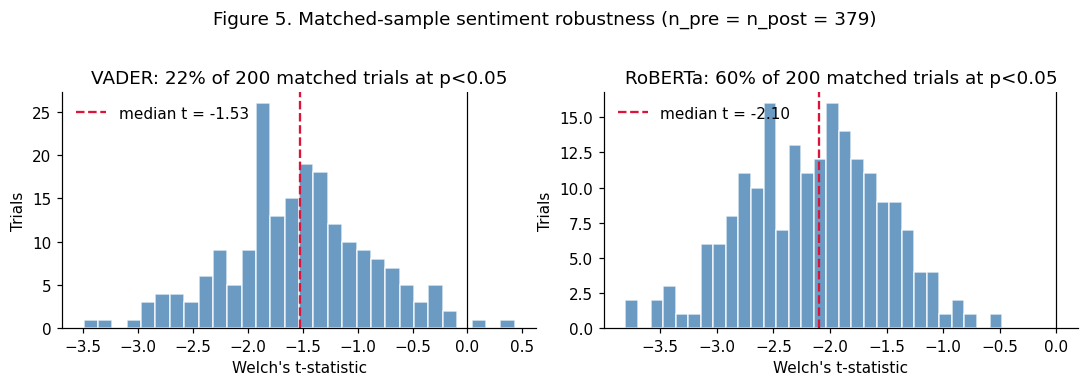

In [5]:
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

for ax, (df_trials, label, full_p) in zip(
    axes, [(vdf, 'VADER',  2.71e-2), (rdf, 'RoBERTa', 3.86e-3)]
):
    ax.hist(df_trials['t'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    pct_sig = (df_trials['p'] < 0.05).mean()
    ax.axvline(df_trials['t'].median(), color='crimson', linestyle='--', linewidth=1.5,
               label=f"median t = {df_trials['t'].median():.2f}")
    ax.set_xlabel("Welch's t-statistic")
    ax.set_ylabel('Trials')
    ax.set_title(f'{label}: {pct_sig:.0%} of 200 matched trials at p<0.05')
    ax.legend(frameon=False, loc='upper left')

plt.suptitle(f'Figure 5. Matched-sample sentiment robustness (n_pre = n_post = {N_PRE})', y=1.02)
plt.tight_layout()
plt.savefig('/content/matched_sample_robustness.png', bbox_inches='tight')
plt.show()

## 5. Extended-stopword LDAThe v1 topics had filler words (`thing`, `way`, `going`, `still`, `year`, `time`, `work`, `people`) crowding interpretable terms. Drop those and refit.Note: case-meaningful terms (`microsoft`, `delta`, `outage`, `company`, `ceo`, `kernel`, `windows`) are **kept**.

In [6]:
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

base_stops = set(stopwords.words('english'))

# v1 stopwords (case + light filler)
v1_extras = {'crowdstrike', 'falcon', 'like', 'would', 'could', 'one', 'get',
             'also', 'really', 'even'}

# v2 additions: filler nouns/verbs that crowded v1 topics
v2_extras = {
    # generic nouns from v1 T2/T4
    'thing', 'things', 'way', 'ways', 'time', 'times', 'work', 'works',
    'people', 'person', 'day', 'days', 'year', 'years', 'week', 'weeks',
    'lot', 'lots', 'bit', 'kind', 'sort', 'stuff',
    # generic adverbs/quantifiers
    'much', 'many', 'still', 'never', 'ever', 'always', 'almost',
    'going', 'go', 'goes', 'gone', 'went',
    # weak evaluation words
    'good', 'bad', 'better', 'worse', 'best', 'worst', 'great',
    # discourse particles
    'yeah', 'yes', 'oh', 'okay', 'ok', 'well', 'maybe', 'probably',
    'actually', 'basically', 'literally',
    # spelled-out numbers (frequent in Reddit)
    'two', 'three', 'four', 'five', 'six', 'ten',
}

stop_words = base_stops | v1_extras | v2_extras
print(f"Total stopwords: {len(stop_words)}  (v2 added {len(v2_extras)})")

lem = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    return [lem.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]

df['tokens'] = df['body'].apply(preprocess)
texts = df['tokens'].tolist()

# Track which docs survive (>=3 tokens)
keep = [len(t) >= 3 for t in texts]
df_topic = df[keep].reset_index(drop=True)
texts_kept = [t for t in texts if len(t) >= 3]

dictionary = corpora.Dictionary(texts_kept)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in texts_kept]

print(f"Documents for LDA: {len(texts_kept)}")
print(f"Vocabulary size:   {len(dictionary)}")

print("\nSelecting k via c_v coherence:")
coh = {}
for k in [4, 5, 6, 7, 8]:
    lda_k = models.LdaModel(corpus, num_topics=k, id2word=dictionary,
                             passes=10, random_state=42, alpha='auto')
    cm = CoherenceModel(model=lda_k, texts=texts_kept, dictionary=dictionary, coherence='c_v')
    coh[k] = cm.get_coherence()
    print(f"  k={k}: coherence={coh[k]:.3f}")

best_k = max(coh, key=coh.get)
print(f"\nSelected k = {best_k}")

lda = models.LdaModel(corpus, num_topics=best_k, id2word=dictionary,
                      passes=20, random_state=42, alpha='auto')

print("\nv2 Topics:")
for tid in range(best_k):
    words = lda.show_topic(tid, topn=10)
    print(f"  T{tid}: {', '.join(w for w,p in words)}")

Total stopwords: 266  (v2 added 58)
Documents for LDA: 3546
Vocabulary size:   2597

Selecting k via c_v coherence:
  k=4: coherence=0.480
  k=5: coherence=0.439
  k=6: coherence=0.433
  k=7: coherence=0.438
  k=8: coherence=0.455

Selected k = 4

v2 Topics:
  T0: outage, company, got, microsoft, last, issue, hour, back, shit, help
  T1: microsoft, window, system, recovery, computer, delta, access, server, software, key
  T2: update, kernel, system, window, software, driver, file, testing, test, linux
  T3: company, product, security, know, use, make, need, business, think, point


## 6. Topic prevalence by window (v2)

In [7]:
def doc_topic_dist(bow):
    return {tid: p for tid, p in lda.get_document_topics(bow, minimum_probability=0)}

topic_dists = [doc_topic_dist(b) for b in corpus]
for tid in range(best_k):
    df_topic[f'topic_{tid}'] = [d.get(tid, 0) for d in topic_dists]

topic_cols = [f'topic_{t}' for t in range(best_k)]
prevalence = df_topic.groupby('window')[topic_cols].mean()

print("Mean topic prevalence by window (v2):")
print(prevalence.round(3))

# delta = post - pre
deltas = (prevalence.loc['post'] - prevalence.loc['pre']).sort_values()
print("\nLargest pre→post shifts (post minus pre):")
for col, d in deltas.items():
    tid = int(col.split('_')[1])
    top_words = ', '.join(w for w,p in lda.show_topic(tid, 5))
    print(f"  T{tid} ({top_words}): {d:+.3f}")

Mean topic prevalence by window (v2):
        topic_0  topic_1  topic_2  topic_3
window                                    
post      0.229    0.168    0.219    0.383
pre       0.276    0.192    0.196    0.335

Largest pre→post shifts (post minus pre):
  T0 (outage, company, got, microsoft, last): -0.047
  T1 (microsoft, window, system, recovery, computer): -0.024
  T2 (update, kernel, system, window, software): +0.023
  T3 (company, product, security, know, use): +0.048


## 7. v2 topic figure

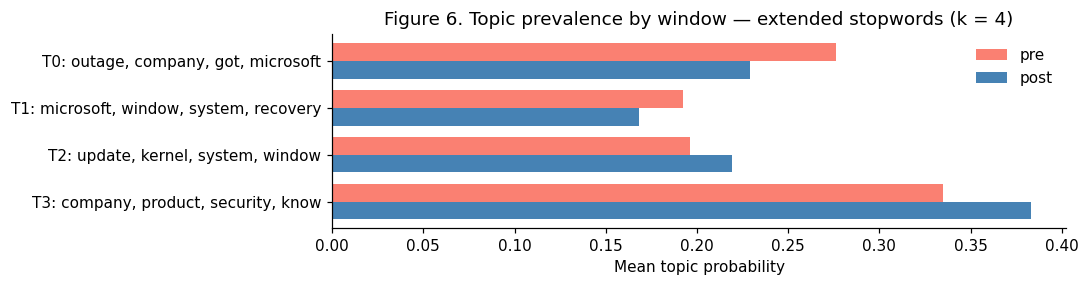

In [8]:
topic_labels = [f'T{i}: {", ".join(w for w,p in lda.show_topic(i, 4))}' for i in range(best_k)]
fig, ax = plt.subplots(figsize=(10, 0.5 + 0.55 * best_k))
x = np.arange(best_k)
w = 0.38
ax.barh(x - w/2, prevalence.loc['pre'].values,  height=w, color='salmon',    label='pre')
ax.barh(x + w/2, prevalence.loc['post'].values, height=w, color='steelblue', label='post')
ax.set_yticks(x); ax.set_yticklabels(topic_labels)
ax.invert_yaxis()
ax.set_xlabel('Mean topic probability')
ax.set_title(f'Figure 6. Topic prevalence by window — extended stopwords (k = {best_k})')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('/content/topic_prevalence_v2.png', bbox_inches='tight')
plt.show()

## 8. Save stats_v2.json

In [9]:
stats_v2 = {
    'robustness_matched_sample': {
        'n_per_group':   N_PRE,
        'n_trials':      N_TRIALS,
        'random_seed':   42,
        'vader':   v_summary,
        'roberta': r_summary,
    },
    'lda_v2': {
        'extended_stopwords_added': sorted(v2_extras),
        'vocabulary_size':          len(dictionary),
        'documents_used':           len(texts_kept),
        'coherence_scores':         {int(k): float(v) for k, v in coh.items()},
        'best_k':                   int(best_k),
        'topic_words':              {int(i): [w for w, p in lda.show_topic(i, 15)] for i in range(best_k)},
        'prevalence_by_window':     {win: {col: float(v) for col, v in row.items()}
                                      for win, row in prevalence.to_dict('index').items()},
        'pre_post_deltas':          {int(col.split('_')[1]): float(d) for col, d in deltas.items()},
    },
}

with open('/content/stats_v2.json', 'w') as f:
    json.dump(stats_v2, f, indent=2)

print("="*60)
print("ROBUSTNESS v2 COMPLETE")
print("="*60)
print(f"Matched VADER:    {v_summary['pct_p_lt_05']:.0%} of trials p<0.05, median t = {v_summary['t_median']:+.2f}")
print(f"Matched RoBERTa:  {r_summary['pct_p_lt_05']:.0%} of trials p<0.05, median t = {r_summary['t_median']:+.2f}")
print(f"v2 LDA:           k = {best_k}, coherence = {coh[best_k]:.3f}")
print()
print("Files saved to /content/:")
for f in ['matched_sample_robustness.png', 'topic_prevalence_v2.png', 'stats_v2.json']:
    path = f'/content/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  ✓ {f}  ({size:,} bytes)")
    else:
        print(f"  ✗ {f}  MISSING")

ROBUSTNESS v2 COMPLETE
Matched VADER:    22% of trials p<0.05, median t = -1.53
Matched RoBERTa:  60% of trials p<0.05, median t = -2.10
v2 LDA:           k = 4, coherence = 0.480

Files saved to /content/:
  ✓ matched_sample_robustness.png  (85,985 bytes)
  ✓ topic_prevalence_v2.png  (77,723 bytes)
  ✓ stats_v2.json  (3,755 bytes)
